In [ ]:
# ============================================================
# CELL 1 — INSTALL / IMPORT
# ============================================================

!pip -q install joblib openpyxl

import os
import json
import zipfile
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import tensorflow as tf
from tensorflow import keras

from google.colab import drive, files

warnings.filterwarnings("ignore")

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPUs: []


In [ ]:
# ============================================================
# CELL 2 — GOOGLE DRIVE + MODEL PATHS
# ============================================================

drive.mount("/content/drive")

PROJECT_DIR = "/content/drive/MyDrive/VO2_Estimation"

MODEL_DIR = os.path.join(
    PROJECT_DIR,
    "outputs_tcn_only",
    "models"
)

VO2_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "best_vo2_tcn.keras"
)

FEATURE_SCALER_PATH = os.path.join(
    MODEL_DIR,
    "vo2_tcn_feature_scaler.joblib"
)

TARGET_SCALER_PATH = os.path.join(
    MODEL_DIR,
    "vo2_tcn_target_scaler.joblib"
)

METADATA_PATH = os.path.join(
    MODEL_DIR,
    "vo2_tcn_metadata.json"
)

INFERENCE_DIR = os.path.join(
    PROJECT_DIR,
    "inference_results"
)

os.makedirs(INFERENCE_DIR, exist_ok=True)

print("=" * 70)
print("CHECKING MODEL ARTIFACTS")
print("=" * 70)

for path in [
    VO2_MODEL_PATH,
    FEATURE_SCALER_PATH,
    TARGET_SCALER_PATH,
    METADATA_PATH
]:
    print(("FOUND   " if os.path.exists(path) else "MISSING "), path)

if not os.path.exists(VO2_MODEL_PATH):
    raise FileNotFoundError(
        "VO2 TCN model not found. Check PROJECT_DIR / MODEL_DIR."
    )

Mounted at /content/drive
CHECKING MODEL ARTIFACTS
FOUND    /content/drive/MyDrive/VO2_Estimation/outputs_tcn_only/models/best_vo2_tcn.keras
FOUND    /content/drive/MyDrive/VO2_Estimation/outputs_tcn_only/models/vo2_tcn_feature_scaler.joblib
FOUND    /content/drive/MyDrive/VO2_Estimation/outputs_tcn_only/models/vo2_tcn_target_scaler.joblib
FOUND    /content/drive/MyDrive/VO2_Estimation/outputs_tcn_only/models/vo2_tcn_metadata.json


In [ ]:
# ============================================================
# CELL 3 — LOAD TCN + SCALERS + METADATA
# ============================================================

vo2_model = keras.models.load_model(VO2_MODEL_PATH)

feature_scaler = joblib.load(FEATURE_SCALER_PATH)
target_scaler = joblib.load(TARGET_SCALER_PATH)

if os.path.exists(METADATA_PATH):
    with open(METADATA_PATH, "r") as f:
        metadata = json.load(f)
else:
    metadata = {}

print("=" * 70)
print("TCN MODEL LOADED")
print("=" * 70)

print("Model input shape:", vo2_model.input_shape)
print("Model output shape:", vo2_model.output_shape)

print("\nMetadata:")
print(json.dumps(metadata, indent=2, default=str))

TCN MODEL LOADED
Model input shape: (None, 30, 2)
Model output shape: (None, 1)

Metadata:
{
  "model": "Temporal Convolutional Network (TCN)",
  "features": [
    "HR_bpm",
    "RMS_movement"
  ],
  "target": "VO2_ml_kg_min",
  "window_size": 30,
  "stride": 5,
  "seed": 42,
  "train_subjects": [
    "subject8",
    "subject7",
    "subject3",
    "subject2"
  ],
  "validation_subjects": [
    "subject4"
  ],
  "test_subjects": [
    "subject5"
  ],
  "best_model_path": "/content/drive/MyDrive/VO2_Estimation/outputs_tcn_only/models/best_vo2_tcn.keras",
  "training_minutes": 0.36697773933410643,
  "test_metrics": {
    "MAE": 4.153481960296631,
    "RMSE": 5.737650006230263,
    "R2": 0.8462659120559692,
    "Pearson_r": 0.9394999146461487,
    "Pearson_p": 2.546727009388317e-200,
    "Spearman_r": 0.8779584172027816,
    "Spearman_p": 2.314650011996586e-138,
    "MAPE_percent": 12.719206809997559,
    "Bias_pred_minus_true": -2.781895637512207,
    "LoA_low": -12.628952026367188,
    

In [ ]:
# ============================================================
# CELL 4 — MATCH TRAINING CONFIGURATION
# ============================================================

# Defaults matching the TCN training shell
FEATURE_COLS = [
    "HR_bpm",
    "RMS_movement"
]

WINDOW_SIZE = 30
STRIDE = 5

# Prefer the exact values saved during training
if "features" in metadata:
    FEATURE_COLS = list(metadata["features"])

if "window_size" in metadata:
    WINDOW_SIZE = int(metadata["window_size"])

if "stride" in metadata:
    STRIDE = int(metadata["stride"])

print("Feature columns:", FEATURE_COLS)
print("Window size    :", WINDOW_SIZE)
print("Stride         :", STRIDE)
print("Model input    :", vo2_model.input_shape)

Feature columns: ['HR_bpm', 'RMS_movement']
Window size    : 30
Stride         : 5
Model input    : (None, 30, 2)


## Upload your reliable dataset ZIP

The ZIP may contain one or multiple CSV files. The shell searches recursively.

Your reliable data should contain, at minimum:

- HR / heart-rate values
- RMS movement values

The inference pipeline does **not** retrain the model.

In [ ]:
# ============================================================
# CELL 5 — UPLOAD RELIABLE DATASET ZIP
# ============================================================

print("=" * 70)
print("UPLOAD YOUR RELIABLE DATASET ZIP")
print("=" * 70)

uploaded = files.upload()

if not uploaded:
    raise RuntimeError("No file uploaded.")

uploaded_name = next(iter(uploaded.keys()))

if not uploaded_name.lower().endswith(".zip"):
    raise ValueError("Please upload a ZIP file.")

UPLOAD_DIR = "/content/uploaded_vo2_dataset"

if os.path.exists(UPLOAD_DIR):
    shutil.rmtree(UPLOAD_DIR)

os.makedirs(UPLOAD_DIR, exist_ok=True)

ZIP_PATH = os.path.join("/content", uploaded_name)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(UPLOAD_DIR)

print("Uploaded:", uploaded_name)
print("Extracted to:", UPLOAD_DIR)

UPLOAD YOUR RELIABLE DATASET ZIP


Saving reliable_dataset (2).zip to reliable_dataset (2).zip
Uploaded: reliable_dataset (2).zip
Extracted to: /content/uploaded_vo2_dataset


In [ ]:
# ============================================================
# CELL 6 — FIND CSV FILES
# ============================================================

all_files = []

for root, dirs, filenames in os.walk(UPLOAD_DIR):
    for filename in filenames:
        all_files.append(os.path.join(root, filename))

csv_files = [
    p for p in all_files
    if p.lower().endswith(".csv")
]

print("=" * 70)
print("CSV FILES FOUND")
print("=" * 70)

for i, path in enumerate(csv_files):
    print(
        f"[{i}]",
        os.path.relpath(path, UPLOAD_DIR)
    )

print("\nCSV count:", len(csv_files))

if not csv_files:
    raise RuntimeError(
        "No CSV files found inside the uploaded ZIP."
    )

CSV FILES FOUND
[0] readiness_validation.csv
[1] training_validation.csv
[2] readiness/all_reliable_segments.csv
[3] readiness/session_summary.csv
[4] readiness/20261002T033729/reliability_flags.csv
[5] readiness/20261002T033729/reliable_only.csv
[6] readiness/20260929T234225/reliability_flags.csv
[7] readiness/20260929T234225/reliable_only.csv
[8] readiness/20260914T025238/reliability_flags.csv
[9] readiness/20260914T025238/reliable_only.csv
[10] readiness/20260913T031758/reliability_flags.csv
[11] readiness/20260913T031758/reliable_only.csv
[12] readiness/20260916T233646/reliability_flags.csv
[13] readiness/20260916T233646/reliable_only.csv
[14] readiness/20260922T235031/reliability_flags.csv
[15] readiness/20260922T235031/reliable_only.csv
[16] readiness/20261004T023249/reliability_flags.csv
[17] readiness/20261004T023249/reliable_only.csv
[18] readiness/20260926T000358/reliability_flags.csv
[19] readiness/20260926T000358/reliable_only.csv
[20] readiness/20260928T235605/reliability_

In [ ]:
# ============================================================
# CELL 7 — COLUMN DETECTION
# ============================================================

def normalize_column_name(col):
    return (
        str(col)
        .strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
    )

def detect_column(columns, candidates):
    normalized = {
        normalize_column_name(c): c
        for c in columns
    }

    for candidate in candidates:
        key = normalize_column_name(candidate)
        if key in normalized:
            return normalized[key]

    for col in columns:
        col_norm = normalize_column_name(col)
        for candidate in candidates:
            candidate_norm = normalize_column_name(candidate)
            if candidate_norm in col_norm:
                return col

    return None

HR_CANDIDATES = [
    "HR_bpm", "HR", "Heart_Rate", "HeartRate",
    "heart_rate", "heart rate", "BPM", "bpm"
]

RMS_CANDIDATES = [
    "RMS_movement", "RMS", "rms", "Movement_RMS",
    "movement_rms", "RMS Movement", "movement"
]

for path in csv_files:
    try:
        preview = pd.read_csv(path, nrows=5)
        hr_col = detect_column(preview.columns, HR_CANDIDATES)
        rms_col = detect_column(preview.columns, RMS_CANDIDATES)

        print("\n" + "=" * 70)
        print(os.path.relpath(path, UPLOAD_DIR))
        print("Columns:", list(preview.columns))
        print("Detected HR :", hr_col)
        print("Detected RMS:", rms_col)
    except Exception as e:
        print("ERROR:", path, e)


readiness_validation.csv
Columns: ['session', 'total_samples', 'reliable_samples', 'reliable_pct', 'n_segments', 'reliable_s', 'longest_segment_s', 'reliable_mean_hr', 'device_avg_hr', 'report_quality', 'rmssd', 'corrected_all_mean_hr', 'all_vs_device_hr']
Detected HR : reliable_mean_hr
Detected RMS: rmssd

training_validation.csv
Columns: ['session', 'total_samples', 'reliable_samples', 'reliable_pct', 'n_segments', 'reliable_s', 'longest_segment_s', 'reliable_mean_hr', 'device_avg_hr', 'report_quality', 'activities', 'session_exertion_level', 'corrected_all_mean_hr', 'reliable_vs_device_hr']
Detected HR : reliable_mean_hr
Detected RMS: None

readiness/all_reliable_segments.csv
Columns: ['session_id', 'segment_id', 'start', 'end', 'duration_s', 'n_samples', 'mean_hr', 'min_hr', 'max_hr', 'mean_hr_quality', 'hr_slope_bpm_min']
Detected HR : mean_hr
Detected RMS: None

readiness/session_summary.csv
Columns: ['session_id', 'session', 'total_samples', 'reliable_samples', 'reliable_pct', 

In [ ]:
# ============================================================
# CELL 8 — PREPROCESS RELIABLE DATA
# ============================================================

def prepare_reliable_dataframe(df, hr_col, rms_col):
    if hr_col is None:
        raise ValueError("Could not detect HR column.")

    if rms_col is None:
        raise ValueError("Could not detect RMS movement column.")

    work = pd.DataFrame({
        "HR_bpm": pd.to_numeric(df[hr_col], errors="coerce"),
        "RMS_movement": pd.to_numeric(df[rms_col], errors="coerce")
    })

    work = work.replace([np.inf, -np.inf], np.nan)

    work = work.dropna(
        subset=["HR_bpm", "RMS_movement"]
    )

    # Basic validity checks
    work = work[
        (work["HR_bpm"] > 0) &
        (work["HR_bpm"] < 250) &
        (work["RMS_movement"] >= 0)
    ]

    return work.reset_index(drop=True)


def create_windows(df, feature_cols, window_size, stride):
    values = df[feature_cols].values.astype(np.float32)

    if len(values) < window_size:
        return (
            np.empty(
                (0, window_size, len(feature_cols)),
                dtype=np.float32
            ),
            []
        )

    windows = []
    starts = []

    for start in range(
        0,
        len(values) - window_size + 1,
        stride
    ):
        end = start + window_size
        windows.append(values[start:end])
        starts.append(start)

    return np.asarray(windows, dtype=np.float32), starts


def scale_windows(X, scaler):
    if len(X) == 0:
        return X

    shape = X.shape
    flat = X.reshape(-1, shape[-1])
    scaled = scaler.transform(flat)

    return scaled.reshape(shape).astype(np.float32)

In [ ]:
# ============================================================
# CELL 9 — RUN TCN VO2 INFERENCE
# ============================================================

all_predictions = []
file_summaries = []

for file_index, csv_path in enumerate(csv_files):

    print("\n" + "#" * 80)
    print(f"PROCESSING {file_index + 1}/{len(csv_files)}")
    print(os.path.relpath(csv_path, UPLOAD_DIR))
    print("#" * 80)

    try:
        df_raw = pd.read_csv(csv_path)

        hr_col = detect_column(
            df_raw.columns,
            HR_CANDIDATES
        )

        rms_col = detect_column(
            df_raw.columns,
            RMS_CANDIDATES
        )

        print("Detected HR :", hr_col)
        print("Detected RMS:", rms_col)

        df = prepare_reliable_dataframe(
            df_raw,
            hr_col,
            rms_col
        )

        print("Reliable samples:", len(df))

        if len(df) < WINDOW_SIZE:
            print("SKIPPED: not enough samples.")
            continue

        X, starts = create_windows(
            df,
            FEATURE_COLS,
            WINDOW_SIZE,
            STRIDE
        )

        print("Temporal windows:", len(X))

        X_scaled = scale_windows(
            X,
            feature_scaler
        )

        pred_scaled = vo2_model.predict(
            X_scaled,
            batch_size=256,
            verbose=1
        ).reshape(-1, 1)

        pred_vo2 = target_scaler.inverse_transform(
            pred_scaled
        ).ravel()

        relative_path = os.path.relpath(
            csv_path,
            UPLOAD_DIR
        )

        for i, prediction in enumerate(pred_vo2):

            start = starts[i]
            end = start + WINDOW_SIZE

            hr_window = df.iloc[start:end]["HR_bpm"]
            rms_window = df.iloc[start:end]["RMS_movement"]

            all_predictions.append({
                "file": relative_path,
                "window_index": i,
                "start_sample": start,
                "end_sample": end,
                "HR_mean_bpm": float(hr_window.mean()),
                "HR_min_bpm": float(hr_window.min()),
                "HR_max_bpm": float(hr_window.max()),
                "RMS_mean": float(rms_window.mean()),
                "RMS_max": float(rms_window.max()),
                "predicted_VO2_mL_kg_min": float(prediction)
            })

        file_summaries.append({
            "file": relative_path,
            "n_raw_samples": int(len(df_raw)),
            "n_reliable_samples": int(len(df)),
            "n_windows": int(len(pred_vo2)),
            "VO2_mean_mL_kg_min": float(np.mean(pred_vo2)),
            "VO2_median_mL_kg_min": float(np.median(pred_vo2)),
            "VO2_std": float(np.std(pred_vo2)),
            "VO2_min_mL_kg_min": float(np.min(pred_vo2)),
            "VO2_max_mL_kg_min": float(np.max(pred_vo2)),
            "HR_mean_bpm": float(df["HR_bpm"].mean()),
            "HR_min_bpm": float(df["HR_bpm"].min()),
            "HR_max_bpm": float(df["HR_bpm"].max()),
            "RMS_mean": float(df["RMS_movement"].mean()),
            "RMS_max": float(df["RMS_movement"].max())
        })

        print(
            f"Estimated file VO2: "
            f"{np.mean(pred_vo2):.2f} mL/kg/min"
        )

    except Exception as e:
        print(
            "ERROR:",
            type(e).__name__,
            str(e)
        )


################################################################################
PROCESSING 1/96
readiness_validation.csv
################################################################################
Detected HR : reliable_mean_hr
Detected RMS: rmssd
Reliable samples: 32
Temporal windows: 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step
Estimated file VO2: 182.99 mL/kg/min

################################################################################
PROCESSING 2/96
training_validation.csv
################################################################################
Detected HR : reliable_mean_hr
Detected RMS: None
ERROR: ValueError Could not detect RMS movement column.

################################################################################
PROCESSING 3/96
readiness/all_reliable_segments.csv
################################################################################
Detected HR : mean_hr
Detected RMS: None
ERROR: ValueError Could not detect RMS movement column.

######

In [ ]:
# ============================================================
# CELL 10 — FINAL RESULTS
# ============================================================

if not all_predictions:
    raise RuntimeError(
        "No predictions were generated. "
        "Check that the ZIP contains CSV files with HR and RMS."
    )

predictions_df = pd.DataFrame(all_predictions)
summary_df = pd.DataFrame(file_summaries)

overall_vo2 = float(
    predictions_df["predicted_VO2_mL_kg_min"].mean()
)

median_vo2 = float(
    predictions_df["predicted_VO2_mL_kg_min"].median()
)

std_vo2 = float(
    predictions_df["predicted_VO2_mL_kg_min"].std()
)

min_vo2 = float(
    predictions_df["predicted_VO2_mL_kg_min"].min()
)

max_vo2 = float(
    predictions_df["predicted_VO2_mL_kg_min"].max()
)

print("\n" + "=" * 70)
print("FINAL VO2 PREDICTION")
print("=" * 70)

print(
    f"Estimated VO2 : {overall_vo2:.2f} mL/kg/min"
)

print(
    f"Median VO2    : {median_vo2:.2f} mL/kg/min"
)

print(
    f"Std           : {std_vo2:.2f}"
)

print(
    f"Min VO2       : {min_vo2:.2f} mL/kg/min"
)

print(
    f"Max VO2       : {max_vo2:.2f} mL/kg/min"
)

print(
    f"Reliable windows: {len(predictions_df)}"
)

print("\nPer-file summary:")
display(summary_df)


FINAL VO2 PREDICTION
Estimated VO2 : 97.69 mL/kg/min
Median VO2    : 71.49 mL/kg/min
Std           : 109.33
Min VO2       : -304.58 mL/kg/min
Max VO2       : 1149.75 mL/kg/min
Reliable windows: 4770

Per-file summary:


,file,n_raw_samples,n_reliable_samples,n_windows,VO2_mean_mL_kg_min,VO2_median_mL_kg_min,VO2_std,VO2_min_mL_kg_min,VO2_max_mL_kg_min,HR_mean_bpm,HR_min_bpm,HR_max_bpm,RMS_mean,RMS_max
0,readiness_validation.csv,32,32,1,182.990997,182.990997,0.000000,182.990997,182.990997,57.493437,47.814,64.879000,157.061156,303.276000
1,training/all_reliable_segments.csv,257,257,46,84.750877,78.892403,18.740591,57.398441,151.295425,135.152818,68.677,177.960769,68.994272,920.372083
2,training/20260917T013556/reliability_flags.csv,834,798,154,118.316505,64.294960,188.968948,-304.576050,999.757935,140.903008,99.790,177.790000,117.669086,1813.412500
3,training/20260917T013556/reliable_only.csv,410,410,77,62.474869,61.279877,22.750608,20.016024,117.359589,141.014732,105.260,176.310000,47.600082,126.021667
4,training/20260922T014354/reliability_flags.csv,1395,1325,260,107.251068,82.554947,100.767899,-167.951996,593.511902,137.495502,92.550,174.550000,110.859290,1727.216667
5,training/20260922T014354/reliable_only.csv,618,618,118,79.876251,77.591003,36.615475,-12.311906,229.961304,135.145566,110.770,174.550000,64.199279,430.560833
6,training/20261001T014913/reliability_flags.csv,1292,1180,231,121.719528,90.081169,113.035141,-224.341736,660.065247,120.395653,51.520,186.480000,129.821035,1896.982500
7,training/20261001T014913/reliable_only.csv,381,381,71,92.043961,89.617615,35.615631,30.176260,211.039856,119.704147,58.180,181.420000,74.407850,629.627500
8,training/20260929T013413/reliability_flags.csv,1393,1320,259,117.490646,80.109123,136.702545,-187.440399,846.362366,135.162962,95.990,173.520000,117.523292,1313.221667
9,training/20260929T013413/reliable_only.csv,542,542,103,102.170746,83.352982,65.271057,-33.327442,302.825928,141.564889,114.880,173.520000,91.140913,836.126667


In [ ]:
# ============================================================
# CELL 11 — PREDICTION TABLE
# ============================================================

display(
    predictions_df.head(30)
)

,file,window_index,start_sample,end_sample,HR_mean_bpm,HR_min_bpm,HR_max_bpm,RMS_mean,RMS_max,predicted_VO2_mL_kg_min
0,readiness_validation.csv,0,0,30,57.566600,47.814000,64.879000,156.859867,303.276000,182.990997
1,training/all_reliable_segments.csv,0,0,30,138.663080,99.719474,169.589048,54.003286,125.767440,69.865669
2,training/all_reliable_segments.csv,1,5,35,134.990100,99.719474,169.589048,57.233012,137.990152,73.494942
3,training/all_reliable_segments.csv,2,10,40,135.353778,99.719474,169.589048,57.839862,137.990152,68.779289
4,training/all_reliable_segments.csv,3,15,45,134.064219,99.719474,169.395217,61.149766,137.990152,78.957947
5,training/all_reliable_segments.csv,4,20,50,132.306092,99.719474,169.395217,63.655989,160.126176,75.162613
6,training/all_reliable_segments.csv,5,25,55,134.957074,105.985556,169.395217,69.562068,182.448389,77.850006
7,training/all_reliable_segments.csv,6,30,60,136.857711,105.985556,169.395217,72.187139,182.448389,86.151863
8,training/all_reliable_segments.csv,7,35,65,140.259991,107.441000,169.395217,68.899598,182.448389,91.107414
9,training/all_reliable_segments.csv,8,40,70,135.746559,107.441000,167.799231,66.729001,182.448389,90.636131


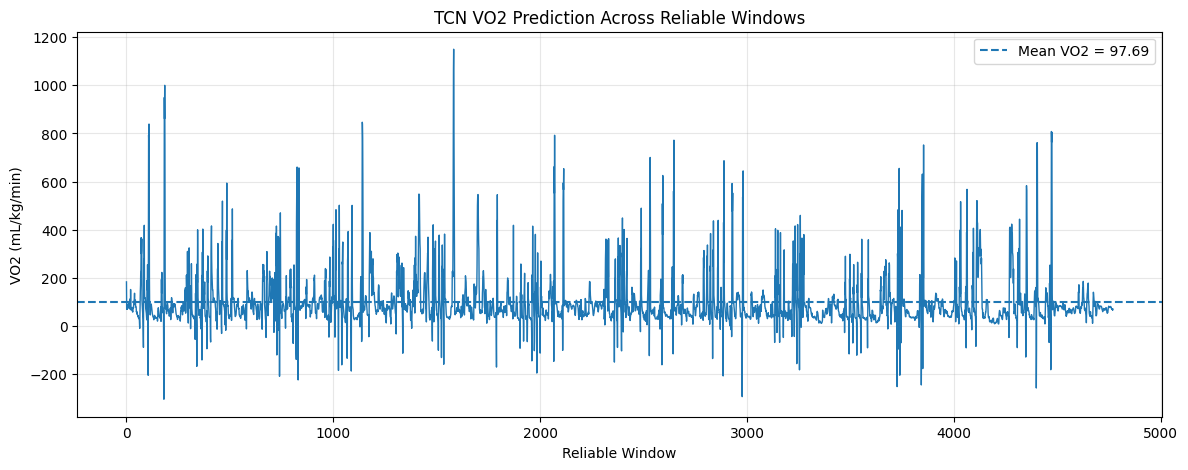

In [ ]:
# ============================================================
# CELL 12 — VO2 OVER TIME
# ============================================================

plt.figure(figsize=(14, 5))

plt.plot(
    predictions_df["predicted_VO2_mL_kg_min"].values,
    linewidth=1
)

plt.axhline(
    overall_vo2,
    linestyle="--",
    label=f"Mean VO2 = {overall_vo2:.2f}"
)

plt.xlabel("Reliable Window")
plt.ylabel("VO2 (mL/kg/min)")
plt.title("TCN VO2 Prediction Across Reliable Windows")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

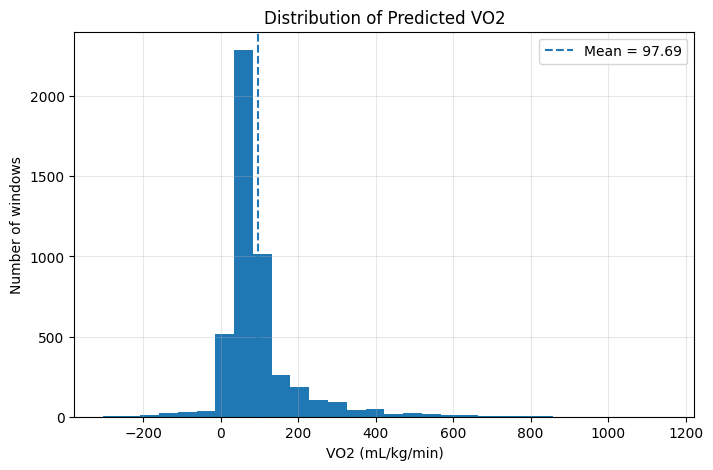

In [ ]:
# ============================================================
# CELL 13 — VO2 DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(
    predictions_df["predicted_VO2_mL_kg_min"],
    bins=30
)

plt.axvline(
    overall_vo2,
    linestyle="--",
    label=f"Mean = {overall_vo2:.2f}"
)

plt.xlabel("VO2 (mL/kg/min)")
plt.ylabel("Number of windows")
plt.title("Distribution of Predicted VO2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

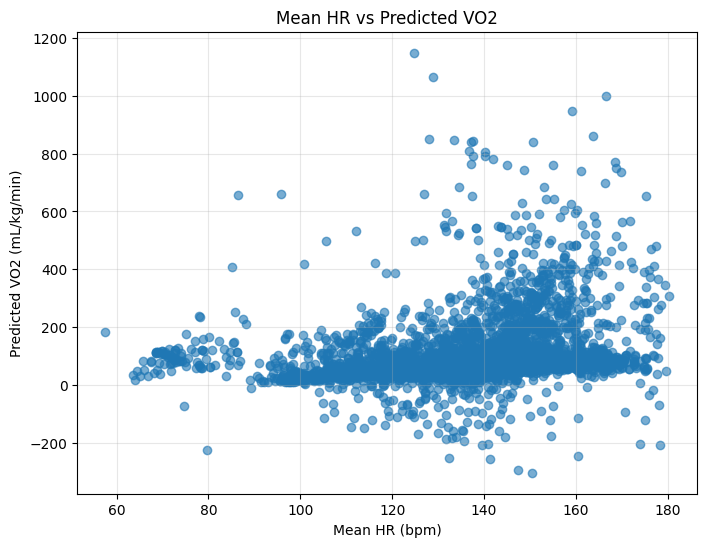

In [ ]:
# ============================================================
# CELL 14 — HR VS PREDICTED VO2
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    predictions_df["HR_mean_bpm"],
    predictions_df["predicted_VO2_mL_kg_min"],
    alpha=0.6
)

plt.xlabel("Mean HR (bpm)")
plt.ylabel("Predicted VO2 (mL/kg/min)")
plt.title("Mean HR vs Predicted VO2")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# ============================================================
# CELL 15 — SAVE RESULTS
# ============================================================

RUN_DIR = os.path.join(
    INFERENCE_DIR,
    "latest_run"
)

if os.path.exists(RUN_DIR):
    shutil.rmtree(RUN_DIR)

os.makedirs(RUN_DIR, exist_ok=True)

predictions_path = os.path.join(
    RUN_DIR,
    "vo2_window_predictions.csv"
)

summary_path = os.path.join(
    RUN_DIR,
    "vo2_session_summary.csv"
)

final_path = os.path.join(
    RUN_DIR,
    "FINAL_VO2_RESULT.csv"
)

predictions_df.to_csv(
    predictions_path,
    index=False
)

summary_df.to_csv(
    summary_path,
    index=False
)

final_result = pd.DataFrame([{
    "estimated_VO2_mL_kg_min": overall_vo2,
    "median_VO2_mL_kg_min": median_vo2,
    "std_VO2": std_vo2,
    "minimum_VO2_mL_kg_min": min_vo2,
    "maximum_VO2_mL_kg_min": max_vo2,
    "number_of_reliable_windows": len(predictions_df),
    "VO2max_status": (
        "NOT AVAILABLE — separate validated VO2max model required"
    )
}])

final_result.to_csv(
    final_path,
    index=False
)

print("Saved:")
print(predictions_path)
print(summary_path)
print(final_path)

Saved:
/content/drive/MyDrive/VO2_Estimation/inference_results/latest_run/vo2_window_predictions.csv
/content/drive/MyDrive/VO2_Estimation/inference_results/latest_run/vo2_session_summary.csv
/content/drive/MyDrive/VO2_Estimation/inference_results/latest_run/FINAL_VO2_RESULT.csv


In [ ]:
# ============================================================
# CELL 16 — CREATE RESULTS ZIP + DOWNLOAD
# ============================================================

RESULT_ZIP = os.path.join(
    INFERENCE_DIR,
    "VO2_Prediction_Results.zip"
)

if os.path.exists(RESULT_ZIP):
    os.remove(RESULT_ZIP)

shutil.make_archive(
    RESULT_ZIP.replace(".zip", ""),
    "zip",
    RUN_DIR
)

print("=" * 70)
print("VO2 PREDICTION COMPLETE")
print("=" * 70)
print("Results ZIP:", RESULT_ZIP)

files.download(RESULT_ZIP)

VO2 PREDICTION COMPLETE
Results ZIP: /content/drive/MyDrive/VO2_Estimation/inference_results/VO2_Prediction_Results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Output

The results ZIP contains:

- `FINAL_VO2_RESULT.csv` — final aggregated VO2 estimate.
- `vo2_session_summary.csv` — per-file/session statistics.
- `vo2_window_predictions.csv` — VO2 prediction for every reliable temporal window.

### VO2max

This notebook intentionally does **not** calculate VO2max by simply taking the maximum predicted VO2 window. That would not be a scientifically valid direct VO2max prediction.

To return both VO2 and VO2max from the same uploaded ZIP, train a separate **VO2max TCN** with measured VO2max labels and add its saved model/scaler to the inference shell.